# Milestone 1

This milestone focuses on understanding the dataset and establishing a baseline performance through **exploratory data analysis (EDA)** and simple **heuristic-based methods** using `librosa`.

---

## Suggested Readings
- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/en/chapter0/introduction)
- [Librosa Documentation](https://librosa.org/doc/main/core.html#audio-loading)

---

## Instructions
Use this notebook to answer **all Milestone-1 questions**.

---

## Resources
- Notebook Link:  
  https://colab.research.google.com/drive/1m6UczhxQIke_raWSqukSWuiKbIVt7MMb?usp=sharing  

- Competition Link:  
  https://www.kaggle.com/competitions/jan-2026-dl-gen-ai-project/


In [91]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [92]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [93]:
# CONFIGURATION
DATA_ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'# Enter dataset path
GENRES = ["blues", "classical", "country", "disco", "hiphop","jazz", "metal", "pop", "reggae", "rock"] # Make the list of all genres available
STEMS = {'bass.wav','drums.wav','other.wav','vocals.wav' } # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0 #Enter index as per Q10.

In [94]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    # Initialize empty dictionaries
    full_dataset =  {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}

    rng = random.Random(seed)

    # ------------------- write your code here -------------------------------

        # Iterate through Genres
        # Check: if genre folder exists
        # CHECK : Completeness (Does it have all stems?)
        # CHECK : Corruption (Is any file too small? (less than 4kb))
        # size checks
        # Stratified Shuffle Split
     #-------------------------------------------------------------------------

            # Helper function to populate dict
    def add_to_dict(target_dict, song_list, stem,genre):
        target_dict[genre][stem].append(song_list)


    corrupted_songs = 0
    less_5mb = 0
    more_5mb = 0
    
    for genre in GENRES:
        path = glob.glob(f"{root_dir}/{genre}")

        
        if path == []:
            print(f"Genre folder doesn't exist for {genre}")
            continue
            
        path_to_stems = glob.glob(f'{path[0]}/*')
        
        for sample in path_to_stems:
            total_stems = glob.glob(f"{sample}/*.wav")
            
            if len(total_stems) != 4:
                print(f"Not all stems found in {sample}")
                print(total_stems)
                
            for stems in total_stems:
                size_in_bytes = os.path.getsize(stems)
                
                if size_in_bytes < (4*1024):
                    print(f"corrupted songs {stem}")
                    corrupted_songs += 1
                    
                if size_in_bytes < (5.0491*1024*1024):
                    less_5mb += 1
                if size_in_bytes > (5.0493*1024*1024 ):
                    more_5mb += 1

                stem = stems.split("/")[-1].replace(".wav","")
                add_to_dict(full_dataset,stems,stem,genre)
        
    print(f'Question 1: corrupted songs count: {corrupted_songs+less_5mb}') 
    print(f'songs with duration less then 5.0491MB: {less_5mb}') 
    print(f'songs with duration more then 5.0493MB: {more_5mb}')
    print(f'Question 2: {abs(less_5mb-more_5mb)} ')

    # now spliting full dataset into test and val datasets
    for genre in GENRES:
        for stem in STEM_KEYS:
            data =  full_dataset[genre][stem]
            train_data, val_data = train_test_split(data, test_size=val_split, random_state=seed)
            train_dataset[genre][stem] = train_data
            val_dataset[genre][stem] = val_data

    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)
print(f'Question 3: {len(tr["reggae"]["drums"]) - len(val["country"]["vocals"])}')
# answers of question 1, 2 , 3

Question 1: corrupted songs count: 1256
songs with duration less then 5.0491MB: 1256
songs with duration more then 5.0493MB: 184
Question 2: 1072 
Question 3: 66


In [95]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
    """
    Input:
        dataset_dict: The dictionary structure {genre: {stem: [paths...]}}
    Output:
        df: Pandas DataFrame containing details of all files with silence >= 5s
    """
    records = []
    # ------------------- write your code here -------------------------------

    total_files = 0     # ---- COUNT TOTAL FILES ----
    for genre in GENRES:
        for stem in STEM_KEYS:
            files = dataset_dict[genre][stem]
            for sample in files:
                # Load Audio
                audio, _  = librosa.load(sample , sr=sr) 
                non_silent = librosa.effects.split(audio, top_db=TOP_DB)
                silence_type = []
                max_silence = 0
                total_silence = 0

                if len(non_silent) == 0:    # CASE A: Fully silent
                    max_silence = len(audio)/sr
                    total_silence = len(audio)/sr
                    silence_type.append("Fully silent")
                    
                else:
                    if (non_silent[0][0] != 0) and (non_silent[0][0]/sr > threshold_sec ) :   # CASE B: START silence
                        if non_silent[0][0]/sr > max_silence:
                            max_silence = non_silent[0][0]/sr
                        total_silence+= non_silent[0][0]/sr
                        silence_type.append("START silence")

                    if (non_silent[-1][-1] != sr*len(audio)) and ((len(audio)-non_silent[-1][-1])/sr >= threshold_sec ) :   # CASE C: END silence
                        if (len(audio)-non_silent[-1][-1])/sr > max_silence:
                            max_silence = (len(audio)-non_silent[-1][-1])/sr
                        total_silence+= (len(audio)-non_silent[-1][-1])/sr
                        silence_type.append("END silence")

                    i = 0
                    j = 1
                    while j < len(non_silent):
                        gap = non_silent[j][0] - non_silent[i][-1]
                        if gap/sr >= threshold_sec:
                            silence_type.append("MIDDLE silence")
                            if gap/sr > max_silence:
                                max_silence = gap/sr 
                            total_silence += gap/sr
                        i+= 1
                        j+= 1

                if silence_type:
                    records.append({
                    "Genre": genre,
                    "Stem": stem,
                    "Duration": round(total_silence, 2),
                    "Max_Silence_Sec": round(max_silence, 2),
                    "Silence_Location": ", ".join(silence_type),
                    "File_Path": sample
                    })
                    
                

        # Find Non-Silent Intervals

        # CASE A: Fully silent
        # CASE B: START silence
        # CASE C: END silence
        # CASE D: MIDDLE silence

        # Store result
        # if max_silence >= threshold_sec:
        #     records.append({
        #         "Genre": genre,
        #         "Stem": stem_name,
        #         "Duration": round(total_duration, 2),
        #         "Max_Silence_Sec": round(max_silence, 2),
        #         "Silence_Location": ", ".join(silence_type),
        #         "File_Path": file_path
        #     })
    #-------------------------------------------------------------------------
    df = pd.DataFrame(records)
    return df


# --- EXECUTION ---
# Pass your 'tr' (training) dictionary here.
# Ensure 'tr' is defined from your previous build_dataset code.
df_silence = find_long_silences(tr, threshold_sec=DURATION, top_db=TOP_DB)
df_silence_val = find_long_silences(val, threshold_sec=DURATION, top_db=TOP_DB)
# --- RESULTS ANALYSIS ---

# ------------------- write your code here -------------------------------
#-------------------------------------------------------------------------



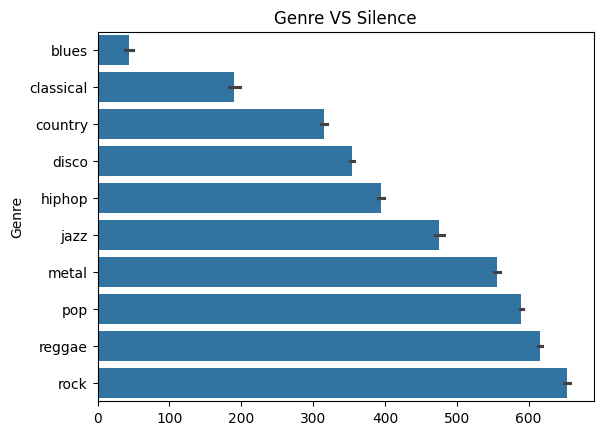

In [96]:
sns.barplot(df_silence["Genre"])
plt.title("Genre VS Silence")
plt.show()

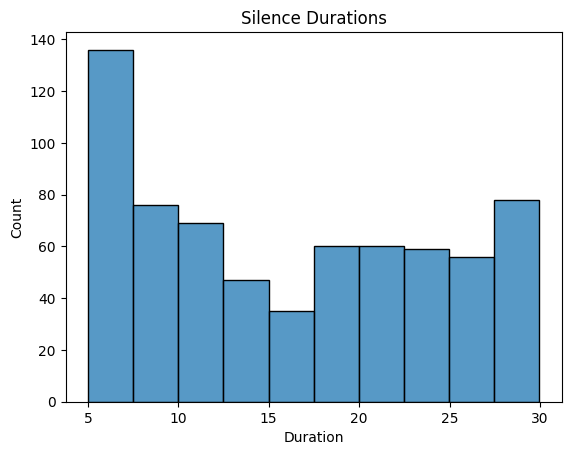

In [97]:
sns.histplot(df_silence["Duration"] , bins = 10 )
plt.title("Silence Durations")
plt.show()

In [98]:
print(f"Question 4: {df_silence.shape[0]}")
print(f"Question 5: {df_silence.loc[df_silence['Stem'] == 'vocals'].count()[0]}")
print(f"Question 6: {df_silence.loc[df_silence['Stem'] == 'vocals', 'Duration'].mean()}")
print(f"Question 7: {df_silence.loc[(df_silence['Stem'] == 'drums') & (df_silence['Genre'] == 'jazz')].count()[0]}")
print(f"Question 8: {df_silence.loc[(df_silence["Stem"] == "drums") & (df_silence["Genre"] == "jazz") & (df_silence["Silence_Location"].str.contains("MIDDLE silence", na=False))].count()[0]}")
print(f"Question 9: {df_silence.loc[(df_silence["Stem"] == "drums") & (df_silence["Genre"] == "jazz") & (df_silence["Max_Silence_Sec"] >= 10 )].count()[0]}")

Question 4: 676
Question 5: 309
Question 6: 16.797799352750808
Question 7: 17
Question 8: 12
Question 9: 4


In [99]:
most_silent_file = df_silence.sort_values(by='Duration' , ascending=False).File_Path[0]
audio , _ = librosa.load(most_silent_file, sr=SR)

import IPython.display as ipd
ipd.display(ipd.Audio(audio , rate=SR))
# printing more silent audio this audio was almost complete silent with some noise

In [100]:
stems_audio = []
try:
    for key in STEM_KEYS:
        audio , _ = librosa.load(tr["rock"][key][0], sr=SR,duration=5.0)
        stems_audio.append(audio)

    print("Audio loaded successfully.")
except NameError:
    print("ERROR: 'tr' dictionary not found. Please run build_dataset() first.")
except IndexError:
    print(f"ERROR: Song index {SONG_INDEX} out of range for genre {GENRE_TO_TEST}.")
except Exception as e:
    print(f"ERROR: {e}")

Audio loaded successfully.


In [101]:
# ------------------- write your code here -------------------------------
# Stack them into a numpy array (Shape: 4 x Samples)
stems_stack = np.vstack(stems_audio)

# Mix the stems by summing them element-wise
mix_raw = stems_stack.sum(axis=0)

# # Calculate RMS Amplitude MANUALLY
rms_val = np.sqrt(np.mean(mix_raw**2))

# #Peak Normalization
max_val = np.max(np.abs(mix_raw))

if max_val > 0:
    mix_norm = mix_raw / max_val
else:
    mix_norm = mix_raw

# VALIDATION
assert np.isclose(np.max(np.abs(mix_norm)), 1.0), "Normalization failed."
#------------------------------------------------------------------------

print(f"Question 10: {stems_stack.shape[1]}")
print(f"Question 11: {rms_val}")
print(f"Question 12: {max_val}")

Question 10: 110250
Question 11: 0.11019725352525711
Question 12: 0.5634763240814209
